# Skład benchmarku — histogramy kategorii (wspólny podzbiór 4k)

Liczby pytań wyłącznie dla **oryginalnego benchmarku** (tabela `claims`, jeden
wiersz na pytanie — bez wyników modeli). Te same 4 000 identyfikatorów stwierdzeń
co w [model_evaluation_analysis.ipynb](model_evaluation_analysis.ipynb), zbudowane
przez `tools/build_subsample_results_db.py` → `results/results_am_subsample.db`.

**Reguły konsolidacji**

| Kategoria | Pole źródłowe | Reguła |
|---|---|---|
| **Odpowiedzi** | `label_original` (== `metadata.correct_answer_index`) | poprawna pozycja odpowiedzi w pytaniu wielokrotnego wyboru, mapowana `0→A, 1→B, 2→C, 3→D` |
| **Lata egzaminów** | `claim_date` | sparsowane numerycznie do roku egzaminu |

Każde stwierdzenie liczone jest raz (deduplikacja ze 112 tys. wierszy wyników
agent×model), więc histogramy opisują sam benchmark, a nie przebieg modelu.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.3)
plt.rcParams["figure.dpi"] = 110

plt.rcParams.update({
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "figure.titlesize": 16,
})

conn = sqlite3.connect("../results/results_am_subsample.db")

# Pytania oryginalnego benchmarku dla TEGO SAMEGO podzbioru 4k (bez wyników modeli).
claims = pd.read_sql_query(
    "SELECT id, topic, claim_date, label_original FROM claims", conn)

# --- Reguły konsolidacji (patrz nagłówek) -------------------------------
ANSWER_LABELS = {0: "A (0)", 1: "B (1)", 2: "C (2)", 3: "D (3)"}
claims["answer"]       = pd.to_numeric(claims["label_original"], errors="coerce").astype("Int64")
claims["answer_label"] = claims["answer"].map(ANSWER_LABELS)
claims["year"]         = pd.to_numeric(claims["claim_date"], errors="coerce").astype("Int64")

print(f"{len(claims):,} unikalnych pytań benchmarku (wspólny podzbiór 4k)".replace(",", " "))
claims.head(3)

4 000 unikalnych pytań benchmarku (wspólny podzbiór 4k)


,id,topic,claim_date,label_original,answer,answer_label,year
0,6,Przyroda,2010,3,3,D (3),2010
1,14,Matematyka,2012,0,0,A (0),2012
2,19,Przyroda,2007,1,1,B (1),2007


## Histogramy — liczba pytań według kategorii

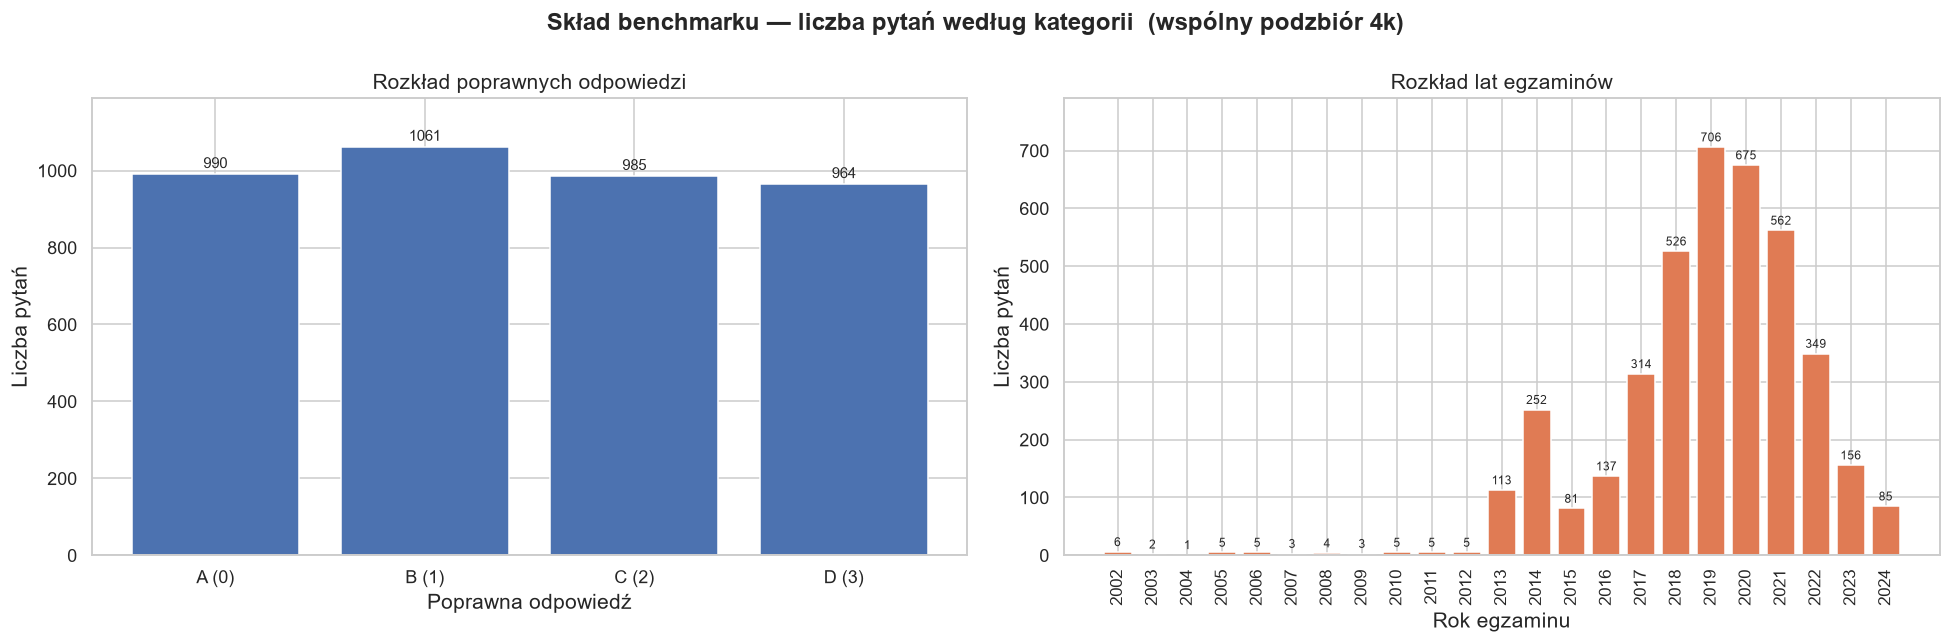

In [2]:
# Dwa histogramy oryginalnego benchmarku — liczba pytań według kategorii
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Skład benchmarku — liczba pytań według kategorii  (wspólny podzbiór 4k)",
             fontsize=16, fontweight="bold")

# 1) Poprawna odpowiedź (A-D / 0-3)
ans = claims["answer_label"].value_counts().reindex([ANSWER_LABELS[i] for i in range(4)])
b1 = axes[0].bar(ans.index, ans.values, color="#4C72B0", edgecolor="white")
axes[0].bar_label(b1, fmt="%d", padding=2, fontsize=10)
axes[0].set_title("Rozkład poprawnych odpowiedzi", fontsize=14)
axes[0].set_xlabel("Poprawna odpowiedź"); axes[0].set_ylabel("Liczba pytań")
axes[0].margins(y=0.12)

# 2) Rok egzaminu
yr = claims["year"].value_counts().sort_index()
b2 = axes[1].bar(yr.index.astype(int).astype(str), yr.values, color="#E07B54", edgecolor="white")
axes[1].bar_label(b2, fmt="%d", padding=2, fontsize=8)
axes[1].set_title("Rozkład lat egzaminów", fontsize=14)
axes[1].set_xlabel("Rok egzaminu"); axes[1].set_ylabel("Liczba pytań")
axes[1].tick_params(axis="x", labelrotation=90, labelsize=11)
axes[1].margins(y=0.12)

plt.tight_layout(); plt.show()

## Podzbiór vs pełny benchmark — reprezentatywność

Porównanie wspólnego podzbioru 4k z **pełnym** benchmarkiem
(`data/benchmarks/am_benchmark.db`, 18 820 pytań) pod względem **roku egzaminu**
oraz **rodziny kategorii**. Liczby znormalizowane do **% pytań**, aby ~4,7-krotna
różnica wielkości nie zniekształcała kształtów — zbliżone słupki oznaczają, że
podzbiór jest reprezentatywny.

`topic_family` konsoliduje 154 surowe tematy: prefiksy kodów egzaminów (`R.13`,
`M.39`, …) zwijają się do `R (kod egzaminu)`, `M (kod egzaminu)`, …; nazwane
przedmioty (Matematyka, Fizyka, …) pozostają bez zmian — ta sama reguła co
w model_evaluation_analysis. Symbole zastępcze `M.XX` / `M.YY` (nierozpoznany numer kwalifikacji w branży M) także wpadają do rodziny `M (kod egzaminu)`.

In [3]:
import re

# Pełny (oryginalny) benchmark — te same kolumny co tabela claims podzbioru.
full = pd.read_sql_query(
    "SELECT id, topic, claim_date, label_original FROM claims",
    sqlite3.connect("file:../data/benchmarks/am_benchmark.db?mode=ro", uri=True))
full["year"] = pd.to_numeric(full["claim_date"], errors="coerce").astype("Int64")

def topic_family(t):
    t = str(t)
    m = re.match(r"^([A-Za-z]+)\.(?:\d|XX|YY)", t)   # kody egzaminów (R.13, M.39) + symbole zastępcze M.XX / M.YY
    return (m.group(1).upper() + " (kod egzaminu)") if m else t

for d in (claims, full):
    d["topic_family"] = d["topic"].apply(topic_family)

print(f"pełny benchmark: {len(full):,} pytań  |  podzbiór 4k: {len(claims):,}".replace(",", " "))

pełny benchmark: 18 820 pytań  |  podzbiór 4k: 4 000


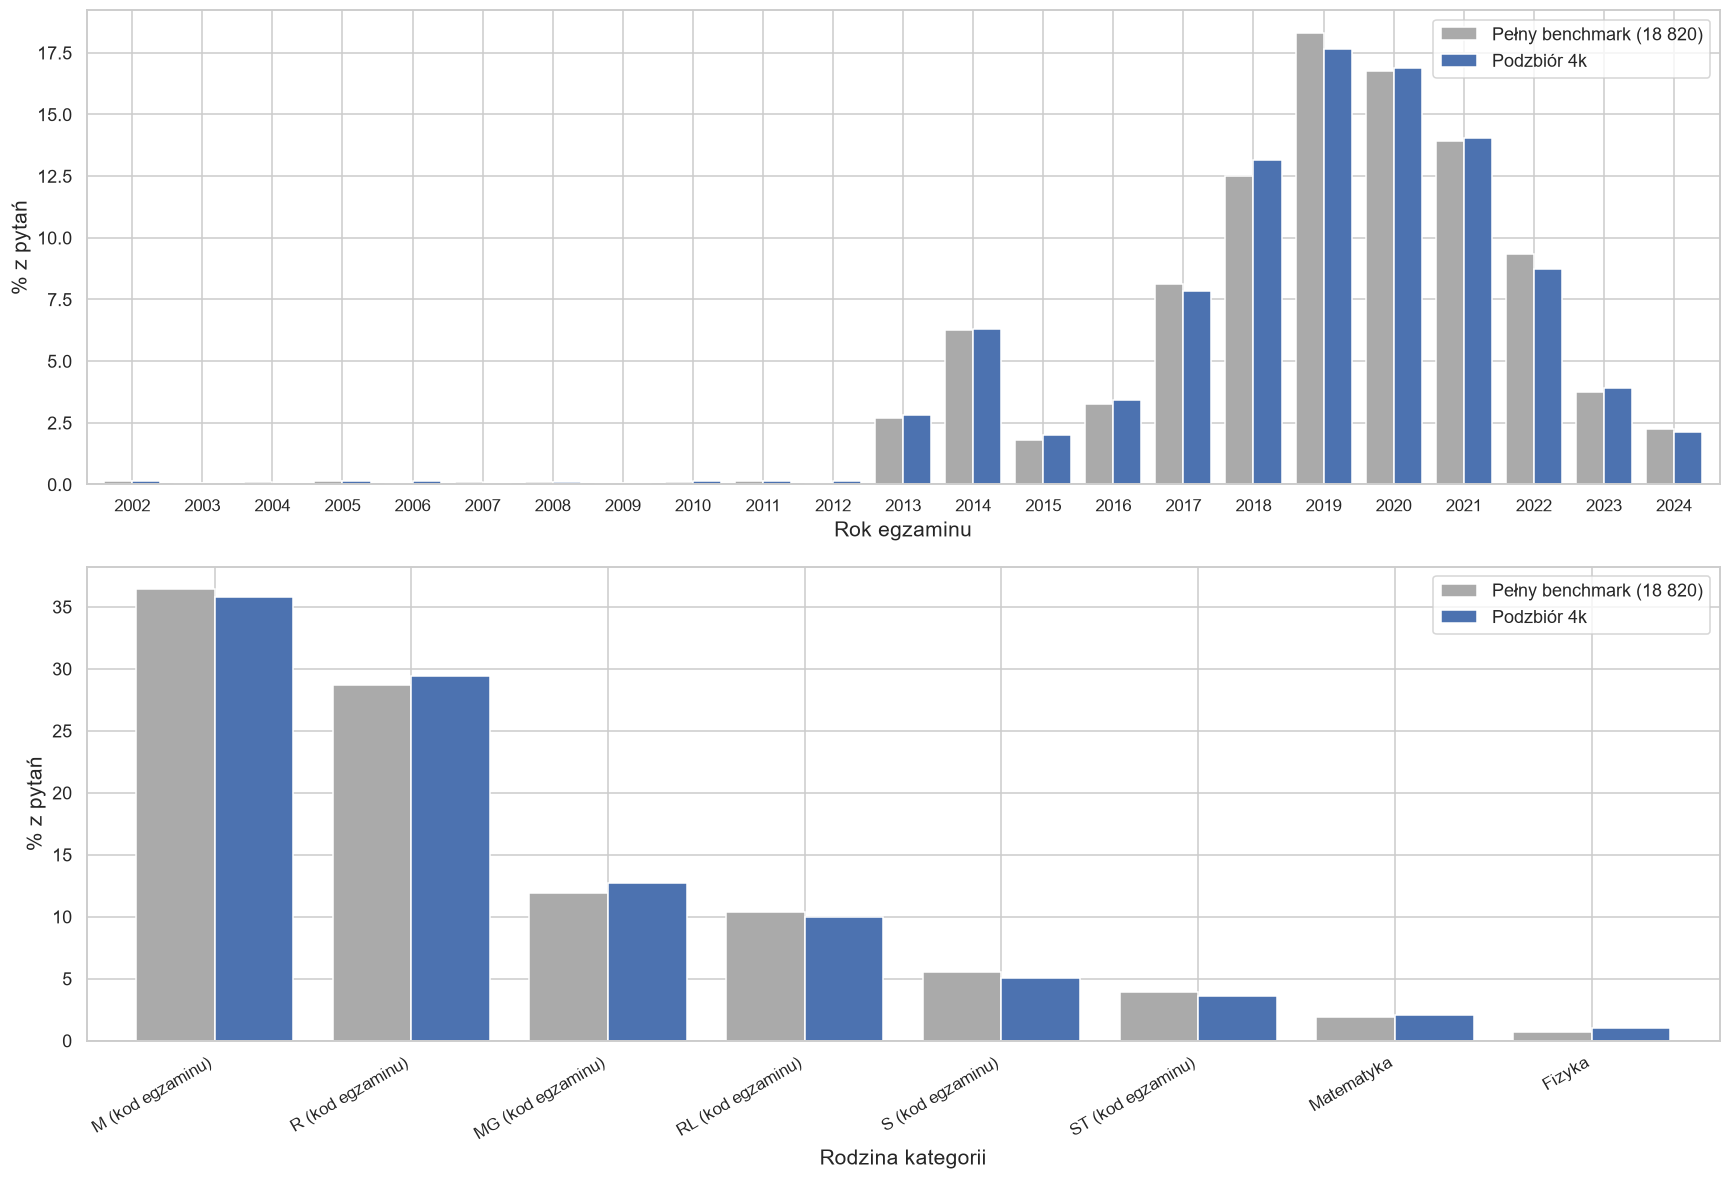

In [4]:
# Dwa porównania (% pytań): podzbiór vs pełny benchmark
CMP_PALETTE = {"Pełny benchmark (18 820)": "#aaaaaa", "Podzbiór 4k": "#4C72B0"}

def pct_compare(col, order):
    out = pd.DataFrame({
        "Pełny benchmark (18 820)": full[col].value_counts(normalize=True) * 100,
        "Podzbiór 4k":              claims[col].value_counts(normalize=True) * 100,
    })
    return out.reindex(order).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(16, 11))

# 1) Rok egzaminu
yc = pct_compare("year", sorted(full["year"].dropna().unique()))
yc.index = yc.index.astype(int).astype(str)
yc.plot.bar(ax=axes[0], color=CMP_PALETTE, edgecolor="white", width=0.8)
axes[0].set_xlabel("Rok egzaminu"); axes[0].set_ylabel("% z pytań")
axes[0].tick_params(axis="x", labelrotation=0, labelsize=11); axes[0].legend(fontsize=12)

# 2) Rodzina kategorii (uporządkowana wg częstości w pełnym benchmarku)
tf_order = full["topic_family"].value_counts().index
tc = pct_compare("topic_family", tf_order)
tc = tc[tc.max(axis=1) >= 1]   # pomiń rodziny poniżej 1% w OBU seriach
tc.plot.bar(ax=axes[1], color=CMP_PALETTE, edgecolor="white", width=0.8)
axes[1].set_xlabel("Rodzina kategorii"); axes[1].set_ylabel("% z pytań")
axes[1].tick_params(axis="x", labelrotation=30, labelsize=11); axes[1].legend(fontsize=12)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout(); plt.show()

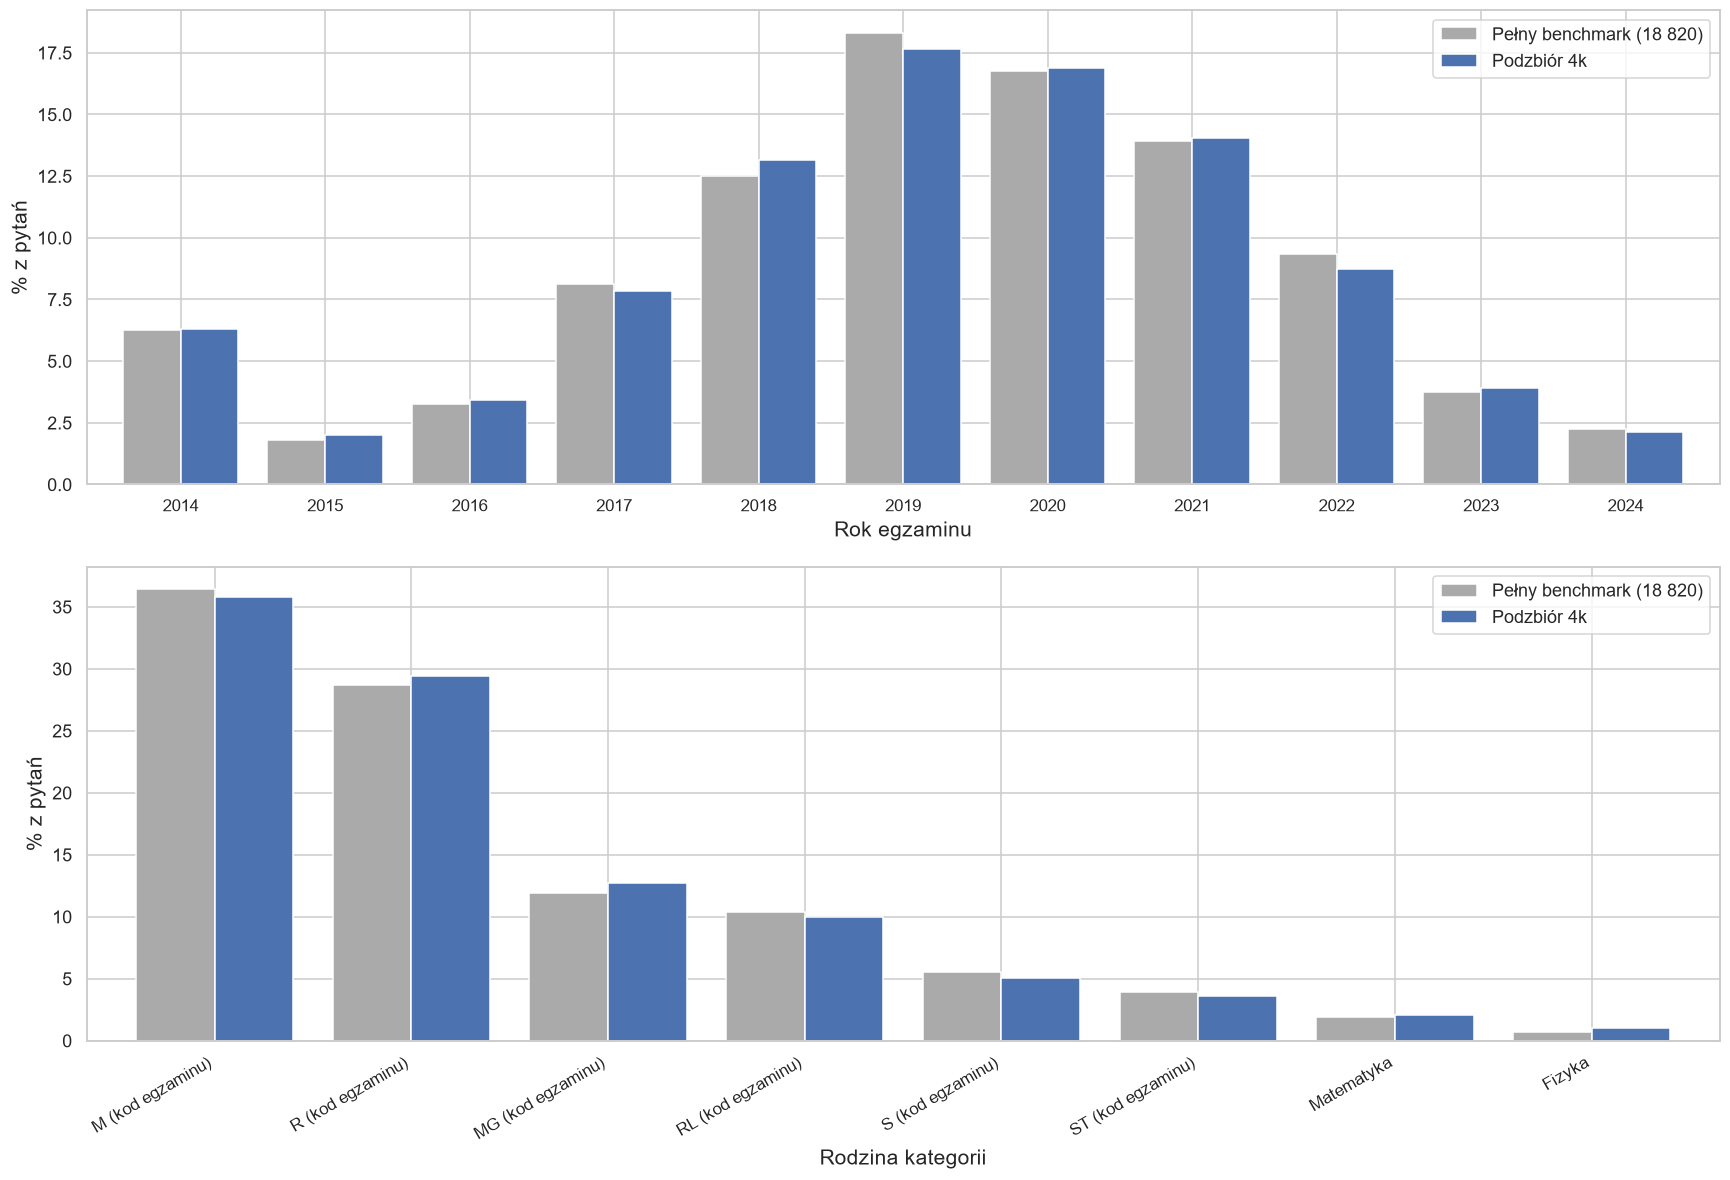

In [5]:
# Dwa porównania (% pytań): podzbiór vs pełny benchmark (lata od 2014)
CMP_PALETTE = {"Pełny benchmark (18 820)": "#aaaaaa", "Podzbiór 4k": "#4C72B0"}

def pct_compare(col, order):
    out = pd.DataFrame({
        "Pełny benchmark (18 820)": full[col].value_counts(normalize=True) * 100,
        "Podzbiór 4k":              claims[col].value_counts(normalize=True) * 100,
    })
    return out.reindex(order).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(16, 11))

# 1) Rok egzaminu (tylko lata > 2013, gdzie jest istotna liczba pytań)
years = [y for y in sorted(full["year"].dropna().unique()) if y > 2013]
yc = pct_compare("year", years)
yc.index = yc.index.astype(int).astype(str)
yc.plot.bar(ax=axes[0], color=CMP_PALETTE, edgecolor="white", width=0.8)
axes[0].set_xlabel("Rok egzaminu"); axes[0].set_ylabel("% z pytań")
axes[0].tick_params(axis="x", labelrotation=0, labelsize=11); axes[0].legend(fontsize=12)

# 2) Rodzina kategorii (uporządkowana wg częstości w pełnym benchmarku)
tf_order = full["topic_family"].value_counts().index
tc = pct_compare("topic_family", tf_order)
tc = tc[tc.max(axis=1) >= 1]   # pomiń rodziny poniżej 1% w OBU seriach
tc.plot.bar(ax=axes[1], color=CMP_PALETTE, edgecolor="white", width=0.8)
axes[1].set_xlabel("Rodzina kategorii"); axes[1].set_ylabel("% z pytań")
axes[1].tick_params(axis="x", labelrotation=30, labelsize=11); axes[1].legend(fontsize=12)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout(); plt.show()